In [1]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("creditcard.csv")

# Separate classes
df_pos = df[df['Class'] == 1]   # all fraud cases
df_neg = df[df['Class'] == 0]   # normal transactions

# Sample negatives
df_neg_sample = df_neg.sample(50000, random_state=42)

# Combine
df_sample = pd.concat([df_neg_sample, df_pos])

# Features and labels
X = df_sample.drop(columns=['Time', 'Class'])
y = df_sample['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine')

embedding = reducer.fit_transform(X_scaled)

df_sample['UMAP1'] = embedding[:, 0]
df_sample['UMAP2'] = embedding[:, 1]

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


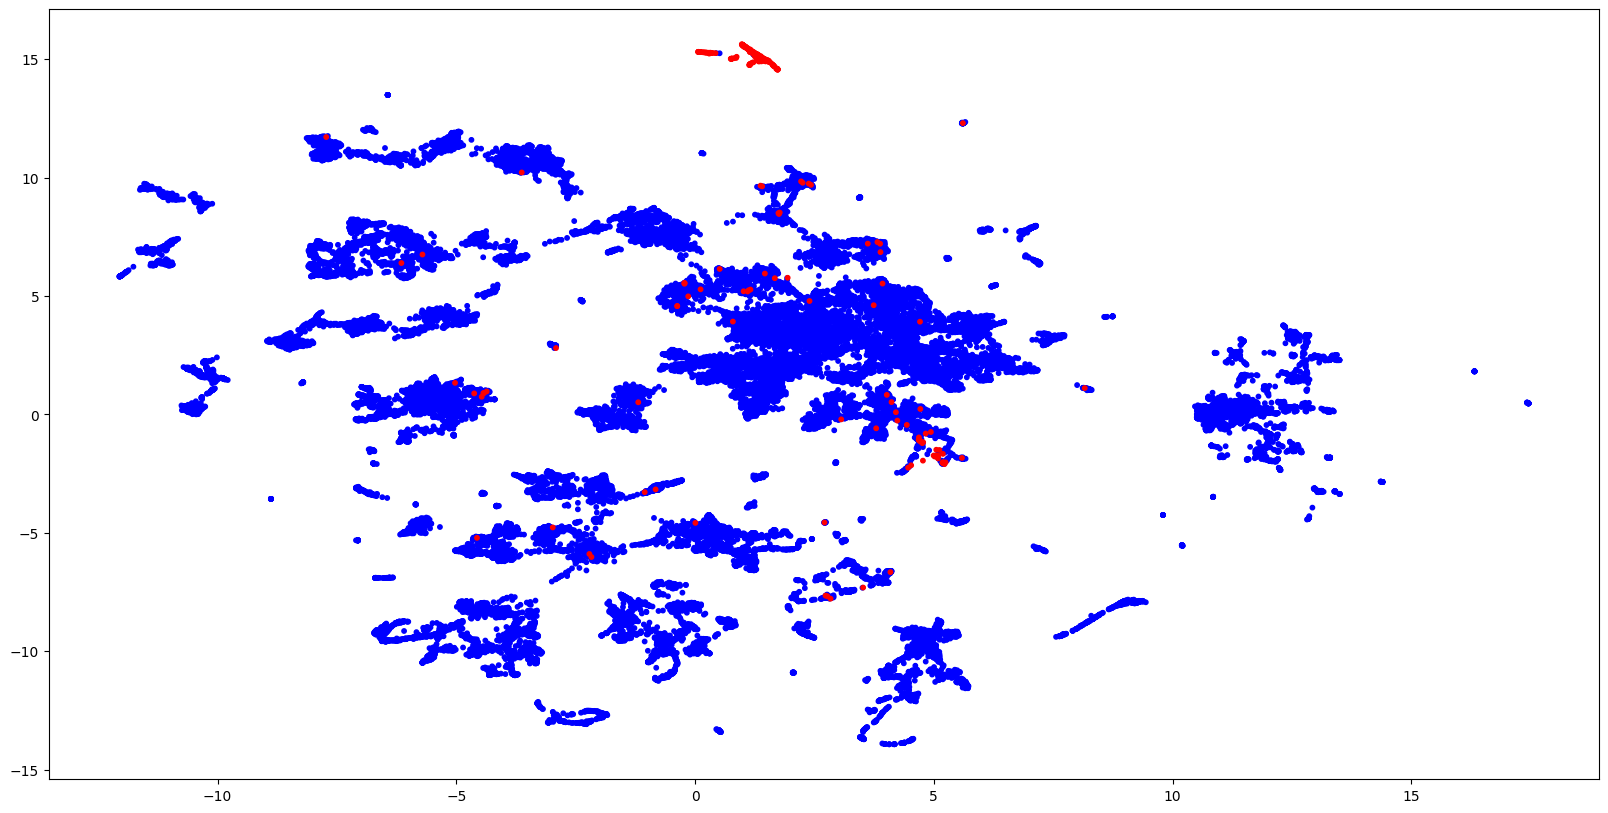

In [2]:
plt.figure(figsize=(20, 10))
plt.scatter(df_sample['UMAP1'], df_sample['UMAP2'], c=y, cmap='bwr', s=10)
plt.show()